In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import seaborn as sns

In [35]:
df2 = pd.read_csv("formulas.csv", index_col=0)
def get_solve_time(code_name):
    if code_name == "Steane":
        return float(df2.loc[r"bv_decide_queries"+"\\"+"steane_dist.cnf"]["solve_time"])
    elif code_name == "Golay":
        return float(df2.loc[r"bv_decide_queries"+"\\"+"golay_dist.cnf"]["solve_time"])
    return(float(df2.loc[r"bv_decide_queries"+"\\"+code_name+"_z_rank.cnf"]["solve_time"]+df2.loc[r"bv_decide_queries"+"\\"+code_name+"_x_rank.cnf"]["solve_time"]+df2.loc[r"bv_decide_queries"+"\\"+code_name+"_x_dist.cnf"]["solve_time"]+df2.loc[r"bv_decide_queries"+"\\"+code_name+"_z_dist.cnf"]["solve_time"]))

Graph successfully generated and saved to: build_times.png


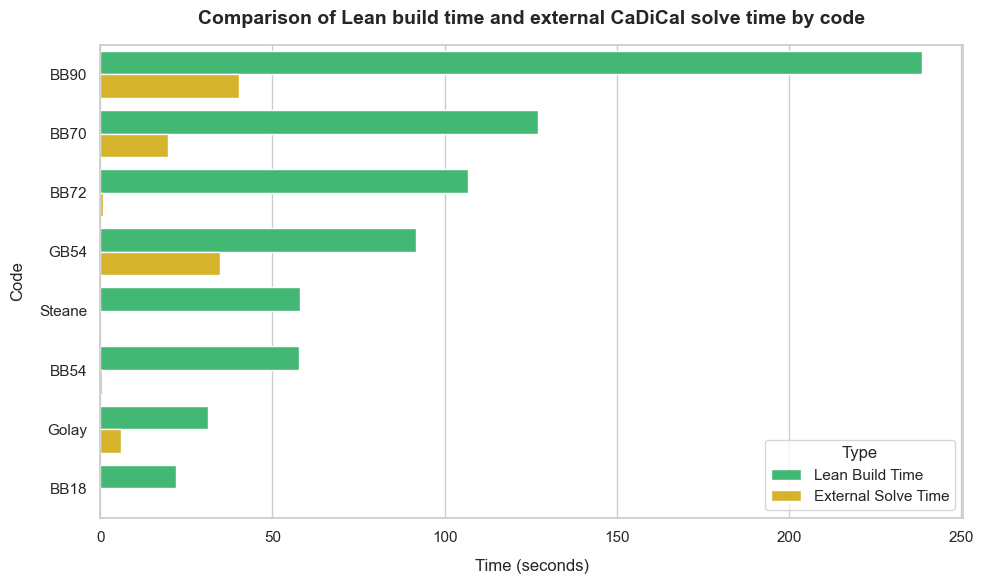

In [37]:
csv_file="build_times.csv"
df = pd.read_csv(csv_file)
name_col = df.columns[0]   # First column (e.g., File Name)
value_col = df.columns[1]  # Second column (e.g., Time)
calculated_col = "External Solve Time"
df[calculated_col] = df[name_col].apply(get_solve_time)
df = df.sort_values(by=value_col, ascending=False)
df_long = pd.melt(
    df, 
    id_vars=[name_col], 
    value_vars=[value_col, calculated_col],
    var_name="Type", 
    value_name="Value"
)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
custom_colors = {value_col: "#2ecc71", calculated_col: "#f1c40f"}
ax = sns.barplot(
    x="Value", 
    y=name_col, 
    hue="Type", 
    data=df_long, 
    palette=custom_colors
)
plt.title(f"Comparison of Lean build time and external CaDiCal solve time by code", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Time (seconds)", fontsize=12, labelpad=10)
plt.ylabel("Code", fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig("build_times.png", dpi=300)
print(f"Graph successfully generated and saved to: {"build_times.png"}")
